给定椭圆弧的参数，将椭圆弧围成的封闭图形转换为多边形

In [23]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import rcParams
import matplotlib.patches as patches


# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['xtick.labelsize'] = 10         # 设置X轴刻度标签的字号
plt.rcParams['ytick.labelsize'] = 10         # 设置Y轴刻度标签的字号

In [2]:
def approx_elliptic(j:npt.NDArray):
    r1, r2 = np.array([0, -1]), np.array([0, 1])    # rihgt hand side
    trans_r = np.vstack([np.dot(j, r1), np.dot(j, r2)])
    print(trans_r)

    u, s, vh = np.linalg.svd(j)
    v = vh.T
    # 是否出现了u和v是否有翻转的情况
    yflip = np.array([[1, 0], [0, -1]])
    if np.linalg.det(u) < 0 and np.linalg.det(vh) < 0:
        u_yflip = u @ yflip
        v_yflip = v @ yflip
    elif np.linalg.det(u) < 0:
        raise ValueError('u is not a rotation matrix')
    elif np.linalg.det(v) < 0:
        raise ValueError('v is not a rotation matrix')
    else:
        u_yflip = u
        v_yflip = v

    # 未旋转椭圆的起点和终点
    r1_tmp = np.dot(np.diag(s) @ v_yflip.T, r1)
    r2_tmp = np.dot(np.diag(s) @ v_yflip.T, r2)

    ang1 = np.degrees(np.arctan2(r1_tmp[1], r1_tmp[0]))
    ang2 = np.degrees(np.arctan2(r2_tmp[1], r2_tmp[0]))

    rot_ang = np.degrees(np.arctan2(u_yflip[1,0], u_yflip[0,0]))
    print(f"Ellipse Rotation Angle: {rot_ang}; Angle Interval: {ang1} ~ {ang2}; Axis: {s}; Area: {np.pi*s[0]*s[1]}")

    return {'s': s, 'rot': rot_ang, 'arc_range': [ang1, ang2], 'trans_r': trans_r}

In [10]:
def ellipse_simplify(j, N):
    # 将椭圆弧线段化为N段
    r1, r2 = np.array([0, -1]), np.array([0, 1])    # rihgt hand side
    dot_product = np.dot(r1, r2)
    theta = np.arccos(dot_product)
    
    r = []
    t_values = np.linspace(0, 1, N)
    for t in t_values:
        rot_ang = t * theta
        rot_mat = np.array([[np.cos(rot_ang), -np.sin(rot_ang)], [np.sin(rot_ang), np.cos(rot_ang)]])
        r_tmp = np.dot(rot_mat, r1)
        r.append(np.dot(j, r_tmp))

    return r

In [ ]:
def ellipse_plot(j):
    dict = approx_elliptic(j)
    s = dict['s']
    rot_ang = dict['rot']
    arc_range = dict['arc_range']
    start_d, end_d = dict['trans_r']

    fig = plt.figure(figsize=(8, 8))
    gs = GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])
    # 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
    ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=arc_range[0], theta2=arc_range[1], color='k', linewidth=2)
    ellipse_arc.set_zorder(2)

    ax.add_patch(ellipse_arc)
    ax.plot([0., start_d[0]], [0., start_d[1]], color='k', linewidth=2, zorder=2)
    ax.plot([0., end_d[0]], [0., end_d[1]], color='k', linewidth=2, zorder=2)
    ax.scatter(0, 0, color='r', s=25, zorder=3)

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, zorder=0)

    plt.tight_layout()

[[-0.1 -0.8]
 [ 0.1  0.8]]
Ellipse Rotation Angle: -133.11090114641922; Angle Interval: 35.98588479751742 ~ -144.0141152024826; Axis: [1.17735059 0.56907433]; Area: 2.1048670779051624


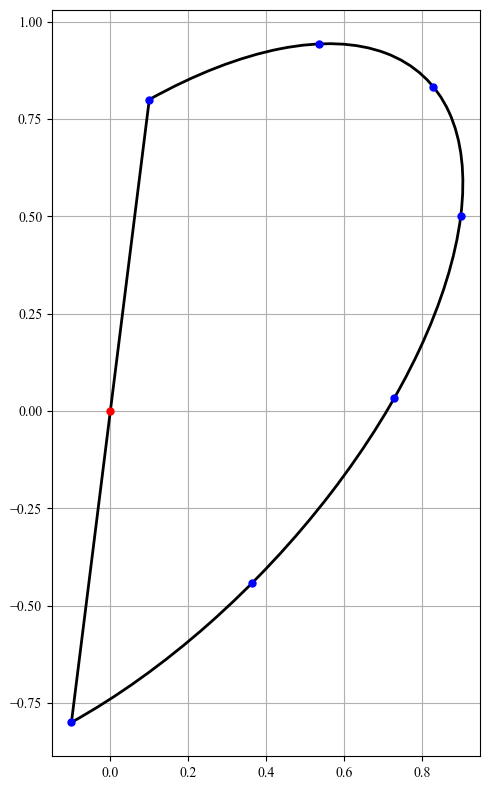

In [32]:
j1 = np.array([[1, 0], [0.1, 1.]])
j2 = np.array([[0.9, 0.1], [0.5, .8]])

dict = approx_elliptic(j2)
s = dict['s']
rot_ang = dict['rot']
ang1, ang2 = dict['arc_range']
start_d, end_d = dict['trans_r']

r = ellipse_simplify(j2, 7)
r_np = np.array(r)

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
# 定义椭圆圆弧的参数:中心点坐标、宽度、高度、旋转角度、开始角度、结束角度
ellipse_arc = patches.Arc((0., 0.), s[0]*2, s[1]*2, angle=rot_ang, theta1=ang1, theta2=ang2, color='k', linewidth=2)
ellipse_arc.set_zorder(2)

ax.add_patch(ellipse_arc)
ax.plot([0., start_d[0]], [0., start_d[1]], color='k', linewidth=2, zorder=2)
ax.plot([0., end_d[0]], [0., end_d[1]], color='k', linewidth=2, zorder=2)
ax.scatter(0, 0, color='r', s=25, zorder=3)

ax.scatter(r_np[:,0], r_np[:,1], color='b', s=25, zorder=3)
# ax.scatter(np.array(x_coords[0]), np.array(y_coords[0]), color='b', s=25, zorder=3)

# ax.set_xlim([-1., 1.])
# ax.set_ylim([-1., 1.])
ax.set_aspect('equal', adjustable='box')
ax.grid(True, zorder=0)

plt.tight_layout()

In [33]:
r1 = ellipse_simplify(j1, 7)
r2 = ellipse_simplify(j2, 7)

poly1 = r1
poly2 = r2
n1, n2 = len(poly1), len(poly2)
result = []

# i, j 分别是两个多边形的当前顶点索引
i, j = 0, 0

while i < n1 or j < n2:
    result.append(poly1[i % n1] + poly2[j % n2])
    
    # 计算边的方向向量
    edge1 = poly1[(i + 1) % n1] - poly1[i % n1]
    edge2 = poly2[(j + 1) % n2] - poly2[j % n2]

    # 比较当前边的角度，选择较小的角度
    cross_product = np.cross(edge1, edge2)
    if cross_product > 0:
        i += 1
    elif cross_product < 0:
        j += 1
    else:
        i += 1
        j += 1

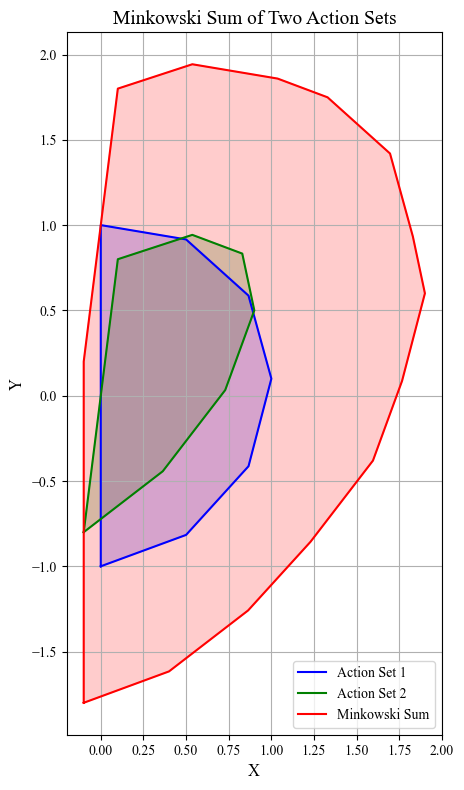

In [36]:
def plot_polygon(vertices, ax:plt.Axes, label, color):
    vertices = np.vstack([vertices, vertices[0]])                   # 闭合多边形
    ax.plot(vertices[:, 0], vertices[:, 1], label=label, color=color)
    ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.2, color=color)

fig = plt.figure(figsize=(8, 8), dpi=100)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])
plot_polygon(poly1, ax, 'Action Set 1', 'blue')
plot_polygon(poly2, ax, 'Action Set 2', 'green')
plot_polygon(result, ax, 'Minkowski Sum', 'red')

ax.set_title('Minkowski Sum of Two Action Sets', fontsize=14)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.legend()
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
# plt.gca().set_aspect('equal', adjustable='box')

In [ ]:
marker_idx = 95
mani_list = [5, 76, 118]

mani_dx_dy = np.zeros((121*2, 2*len(mani_list)))

# 读取数据
for idx in mani_list:
    dx_dy_tmp = np.loadtxt(f'dx_dy-contact_idx_{idx}.csv', delimiter=',')
    mani_dx_dy[:, 2*mani_list.index(idx):2*(mani_list.index(idx)+1)] = dx_dy_tmp
    
np.savetxt('mani_dx_dy-marker_95.csv', mani_dx_dy, fmt='%f', delimiter=',')